# 08 — EDA: Joined Dataset (flights_featured)

With all data sources merged into one flight-level table we can ask questions that required
multiple notebooks before: how does weather intensity scale with delay, which departure windows
are most exposed to storms, do monopoly routes behave differently, and which cities feed the most
passengers into DMV airports.

**Source:** `data/processed/flights_featured.parquet` — 2.8 M rows, all DMV departures 2015-2025.

---
| Section | Topic |
|---------|-------|
| 1 | Dataset Overview |
| 2 | Visibility Threshold Effect on Delay |
| 3 | Weather Type vs. Delay Severity |
| 4 | Departure Window × Thunderstorm Interaction |
| 5 | Season × Airport Delay Heatmap |
| 6 | Carrier On-Time Performance by Airport |
| 7 | Route Monopoly and On-Time Rate |
| 8 | Fare Level vs. Delay |
| 9 | International Feeder Airports into DMV |
| 10 | Summary & Key Findings |
| 11 | NAS Delay Trend: The Staffing Crisis Signal |
| 12 | Carrier Market Share by Airport |
| 13 | Annual Flight Volume and the COVID Dip |
| 14 | Shared Destination Markets |

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import PROCESSED_DATA_PATH

AIRPORTS = ['IAD', 'DCA', 'BWI']
AIRPORT_COLORS = {'IAD': '#1f77b4', 'DCA': '#ff7f0e', 'BWI': '#2ca02c'}

feat = pd.read_parquet(PROJECT_ROOT / PROCESSED_DATA_PATH / 'flights_featured.parquet')
feat['FlightDate'] = pd.to_datetime(feat['FlightDate'])

# Operated (non-cancelled) flights are the basis for delay analysis
operated = feat[feat['Cancelled'] == 0].copy()

print(f'flights_featured: {len(feat):,} total rows  ({len(operated):,} operated)')
print(f'Columns: {feat.shape[1]}')
print(f'Date range: {feat["FlightDate"].min().date()} to {feat["FlightDate"].max().date()}')

flights_featured: 2,823,044 total rows  (2,754,055 operated)
Columns: 53
Date range: 2015-01-01 to 2026-01-31


## Section 1 — Dataset Overview

Quick snapshot of the joined dataset: join coverage, target variable distributions,
and the overall share of feature columns that are populated.

In [2]:
print('=== Join Coverage (all rows) ===')
for label, col in [
    ('NOAA weather',   'wx_min_vis'),
    ('T-100 capacity', 't100_seats'),
    ('DB1B fare',      'db1b_avg_fare'),
]:
    n = int(feat[col].notna().sum())
    pct = n / len(feat) * 100
    print(f'  {label:<18}: {n:>10,}  ({pct:.1f}%)')

print()
print('=== Delay & Cancellation Summary ===')
cancel_pct  = feat['Cancelled'].mean() * 100
late_pct    = operated['is_late'].mean() * 100
mean_delay  = operated['ArrDelayMinutes'].mean()
print(f'  Cancellation rate:          {cancel_pct:.2f}%')
print(f'  Late rate (operated):       {late_pct:.1f}%')
print(f'  Mean arrival delay:         {mean_delay:.1f} min')

print()
print('=== Late Rate by Airport ===')
for ap in AIRPORTS:
    sub = operated[operated['Origin'] == ap]
    lr  = sub['is_late'].mean() * 100
    md  = sub['ArrDelayMinutes'].mean()
    print(f'  {ap}: {lr:.1f}% late  |  {md:.1f} min mean delay  |  {len(sub):,} flights')

=== Join Coverage (all rows) ===
  NOAA weather      :  2,697,299  (95.5%)
  T-100 capacity    :  2,822,647  (100.0%)
  DB1B fare         :  2,644,388  (93.7%)

=== Delay & Cancellation Summary ===
  Cancellation rate:          2.44%
  Late rate (operated):       19.0%
  Mean arrival delay:         14.2 min

=== Late Rate by Airport ===
  IAD: 17.3% late  |  14.3 min mean delay  |  549,568 flights
  DCA: 19.0% late  |  14.9 min mean delay  |  1,193,670 flights
  BWI: 20.1% late  |  13.2 min mean delay  |  1,010,817 flights


## Section 2 — Visibility Threshold Effect on Delay

Aviation visibility is categorised into four FAA flight-rule bands:

- **LIFR** — Low Instrument Flight Rules: visibility < 1 mile. Requires Category II/III precision approaches.
- **IFR** — Instrument Flight Rules: visibility 1–3 miles. Pilots must file and fly instrument procedures.
- **MVFR** — Marginal Visual Flight Rules: visibility 3–5 miles. Legal VFR but reduced separation margins.
- **VFR** — Visual Flight Rules: visibility > 5 miles. Normal operations.

If low visibility directly drives delays we should see a step-change at the IFR threshold (3 mi)
and again at LIFR (1 mi). Using the minimum daily visibility at the departure airport, we compare
mean delay and late rate across all six buckets.

                mean_delay  late_pct_disp  n_flights
vis_cat                                             
LIFR (<1 mi)        23.820           29.5     142336
IFR (1-3 mi)        20.491           26.1     282832
MVFR (3-5 mi)       18.446           23.2     194900
VFR (5-10 mi)       14.688           19.7     619908
Clear (>10 mi)      10.925           15.4    1385433
No wx data          15.444           21.2     122595



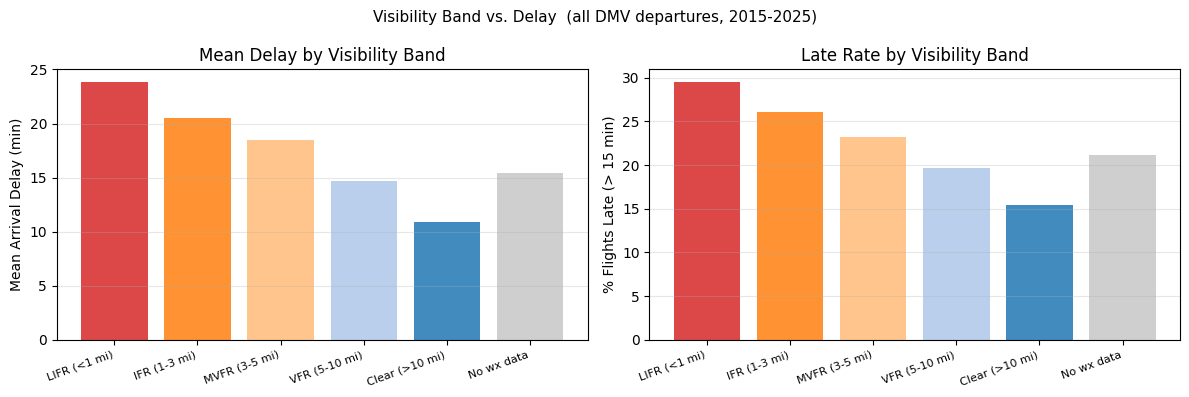

In [3]:
vis = operated['wx_min_vis']
operated['vis_cat'] = np.select(
    [vis.isna(), vis < 1, vis < 3, vis < 5, vis < 10],
    ['No wx data', 'LIFR (<1 mi)', 'IFR (1-3 mi)', 'MVFR (3-5 mi)', 'VFR (5-10 mi)'],
    default='Clear (>10 mi)',
)

vis_order = ['LIFR (<1 mi)', 'IFR (1-3 mi)', 'MVFR (3-5 mi)', 'VFR (5-10 mi)', 'Clear (>10 mi)', 'No wx data']
vis_stats = (
    operated.groupby('vis_cat')
    .agg(
        mean_delay = ('ArrDelayMinutes', 'mean'),
        late_pct   = ('is_late',         'mean'),
        n_flights  = ('ArrDelayMinutes', 'count'),
    )
    .reindex(vis_order)
    .round(3)
)
vis_stats['late_pct_disp'] = (vis_stats['late_pct'] * 100).round(1)
print(vis_stats[['mean_delay', 'late_pct_disp', 'n_flights']].to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cats = [c for c in vis_order if c in vis_stats.index and vis_stats.loc[c, 'n_flights'] > 100]
colors = ['#d62728','#ff7f0e','#ffbb78','#aec7e8','#1f77b4','#c7c7c7']

ax = axes[0]
vals = [vis_stats.loc[c, 'mean_delay'] for c in cats]
ax.bar(range(len(cats)), vals, color=colors[:len(cats)], alpha=0.85)
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Mean Arrival Delay (min)')
ax.set_title('Mean Delay by Visibility Band')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
vals = [vis_stats.loc[c, 'late_pct_disp'] for c in cats]
ax.bar(range(len(cats)), vals, color=colors[:len(cats)], alpha=0.85)
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('% Flights Late (> 15 min)')
ax.set_title('Late Rate by Visibility Band')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Visibility Band vs. Delay  (all DMV departures, 2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 3 — Weather Type vs. Delay Severity

Thunderstorms, snow, and fog are operationally distinct: thunderstorms are brief and intense,
snow can last hours and close runways, fog degrades visibility without wind.
We assign each flight-day to the most operationally severe condition observed
(thunderstorm > snow > fog > clear) and compare delay profiles.

C:\Users\kabec\AppData\Local\Temp\ipykernel_89048\431424891.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ts   = operated['wx_had_ts'].fillna(False)
C:\Users\kabec\AppData\Local\Temp\ipykernel_89048\431424891.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snow = operated['wx_had_snow'].fillna(False)
C:\Users\kabec\AppData\Local\Temp\ipykernel_89048\431424891.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in 

                 Mean Delay (min)  Late %  Flights
wx_type                                           
Thunderstorm               32.003    33.1   227661
Snow                       23.872    30.4    89826
Fog / Mist                 14.733    21.0   575223
Clear / Unknown            11.325    16.1  1855294



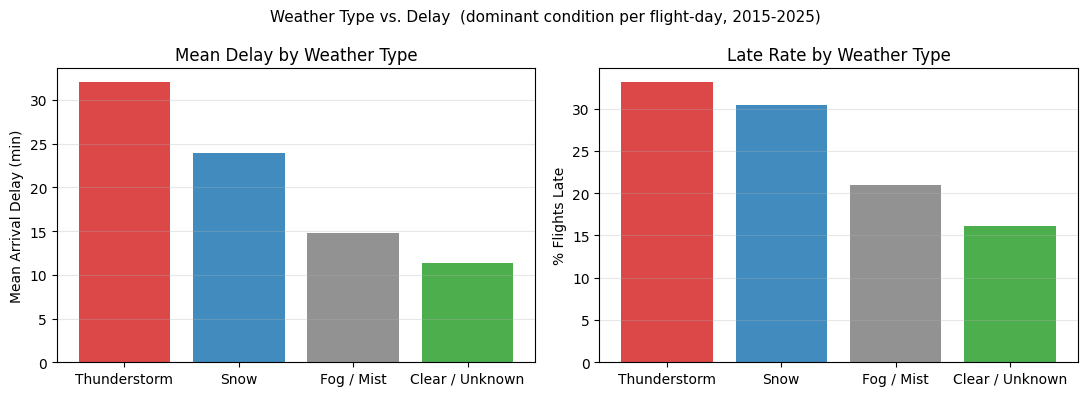

In [4]:
ts   = operated['wx_had_ts'].fillna(False)
snow = operated['wx_had_snow'].fillna(False)
fog  = operated['wx_had_fog'].fillna(False)

operated['wx_type'] = np.select(
    [ts, snow, fog],
    ['Thunderstorm', 'Snow', 'Fog / Mist'],
    default='Clear / Unknown',
)

wx_order = ['Thunderstorm', 'Snow', 'Fog / Mist', 'Clear / Unknown']
wx_stats = (
    operated.groupby('wx_type')
    .agg(
        mean_delay  = ('ArrDelayMinutes', 'mean'),
        late_pct    = ('is_late',         'mean'),
        cancel_pct  = ('Cancelled',       lambda x: 0),
        n_flights   = ('ArrDelayMinutes', 'count'),
    )
    .reindex(wx_order)
    .round(3)
)
wx_stats['late_pct_disp'] = (wx_stats['late_pct'] * 100).round(1)
print(wx_stats[['mean_delay', 'late_pct_disp', 'n_flights']].rename(
    columns={'mean_delay':'Mean Delay (min)','late_pct_disp':'Late %','n_flights':'Flights'}
).to_string())
print()

wx_colors = {'Thunderstorm': '#d62728', 'Snow': '#1f77b4', 'Fog / Mist': '#7f7f7f', 'Clear / Unknown': '#2ca02c'}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
vals = [wx_stats.loc[w, 'mean_delay'] for w in wx_order]
ax.bar(range(len(wx_order)), vals, color=[wx_colors[w] for w in wx_order], alpha=0.85)
ax.set_xticks(range(len(wx_order)))
ax.set_xticklabels(wx_order)
ax.set_ylabel('Mean Arrival Delay (min)')
ax.set_title('Mean Delay by Weather Type')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
vals = [wx_stats.loc[w, 'late_pct_disp'] for w in wx_order]
ax.bar(range(len(wx_order)), vals, color=[wx_colors[w] for w in wx_order], alpha=0.85)
ax.set_xticks(range(len(wx_order)))
ax.set_xticklabels(wx_order)
ax.set_ylabel('% Flights Late')
ax.set_title('Late Rate by Weather Type')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Weather Type vs. Delay  (dominant condition per flight-day, 2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 4 — Departure Window × Thunderstorm Interaction

Afternoon convection peaks 14-17 EDT (18-21 UTC) — directly overlapping the busiest
departure bank. We test whether the afternoon window is disproportionately harmed
when a thunderstorm occurs, compared to other departure periods.

C:\Users\kabec\AppData\Local\Temp\ipykernel_89048\102617646.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  op2['had_ts'] = op2['wx_had_ts'].fillna(False)


Mean arrival delay (min) by departure window and thunderstorm:
                 No Thunderstorm  Thunderstorm Day  lift
dep_hour_bucket                                         
Early                        7.8               9.3   1.5
Morning                      9.2              11.6   2.4
Afternoon                   14.3              41.5  27.3
Evening                     17.6              60.7  43.1
Night                       15.2              47.3  32.1



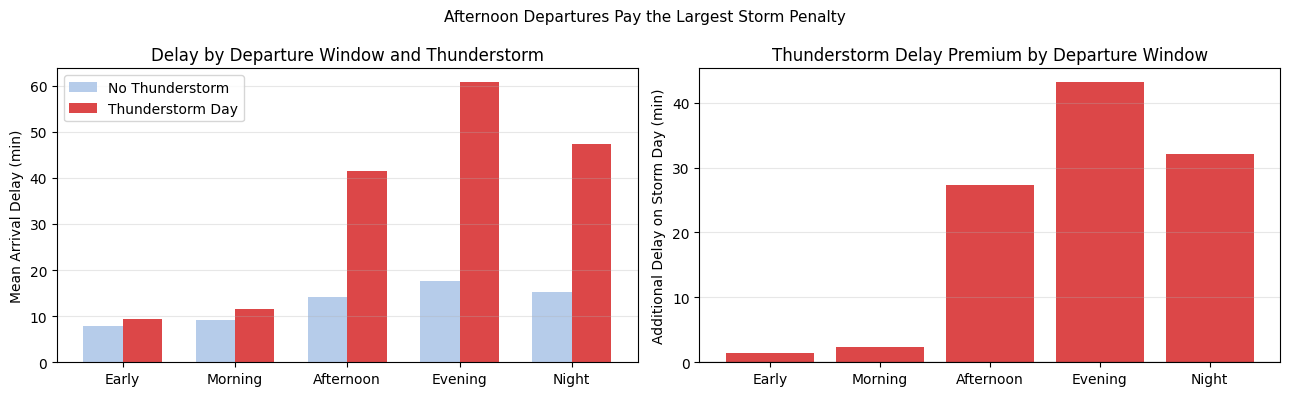

In [5]:
bucket_order = ['Early', 'Morning', 'Afternoon', 'Evening', 'Night']
op2 = operated[operated['dep_hour_bucket'].isin(bucket_order)].copy()
op2['had_ts'] = op2['wx_had_ts'].fillna(False)

interaction = (
    op2.groupby(['dep_hour_bucket', 'had_ts'])
    .agg(mean_delay=('ArrDelayMinutes', 'mean'), n=('ArrDelayMinutes', 'count'))
    .reset_index()
)
ts_pivot = interaction.pivot(index='dep_hour_bucket', columns='had_ts', values='mean_delay')
ts_pivot = ts_pivot.reindex(bucket_order)
ts_pivot.columns = ['No Thunderstorm', 'Thunderstorm Day']
ts_pivot['lift'] = ts_pivot['Thunderstorm Day'] - ts_pivot['No Thunderstorm']

print('Mean arrival delay (min) by departure window and thunderstorm:')
print(ts_pivot.round(1).to_string())
print()

x = np.arange(len(bucket_order))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(x - w/2, ts_pivot['No Thunderstorm'],  w, label='No Thunderstorm',  color='#aec7e8', alpha=0.9)
ax.bar(x + w/2, ts_pivot['Thunderstorm Day'], w, label='Thunderstorm Day', color='#d62728', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bucket_order)
ax.set_ylabel('Mean Arrival Delay (min)')
ax.set_title('Delay by Departure Window and Thunderstorm')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
lift_vals = ts_pivot['lift'].values
bar_colors = ['#d62728' if v > 0 else '#2ca02c' for v in lift_vals]
ax.bar(x, lift_vals, color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bucket_order)
ax.set_ylabel('Additional Delay on Storm Day (min)')
ax.set_title('Thunderstorm Delay Premium by Departure Window')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Afternoon Departures Pay the Largest Storm Penalty', fontsize=11)
plt.tight_layout()
plt.show()

## Section 5 — Season × Airport Delay Heatmap

The late rate shown here is the **overall** percentage of operated flights that arrived
more than 15 minutes late — all causes combined (carrier, NAS, weather, late aircraft),
not just weather-driven delays. This gives a complete picture of when each airport is
generally hardest to fly reliably, regardless of why.

Delay drivers differ by season: winter brings snow and ice worst at IAD (more inland,
colder than DCA), summer brings afternoon thunderstorms worst at DCA (urban heat, Potomac
moisture). A heatmap makes the airport × season interaction legible at a glance.

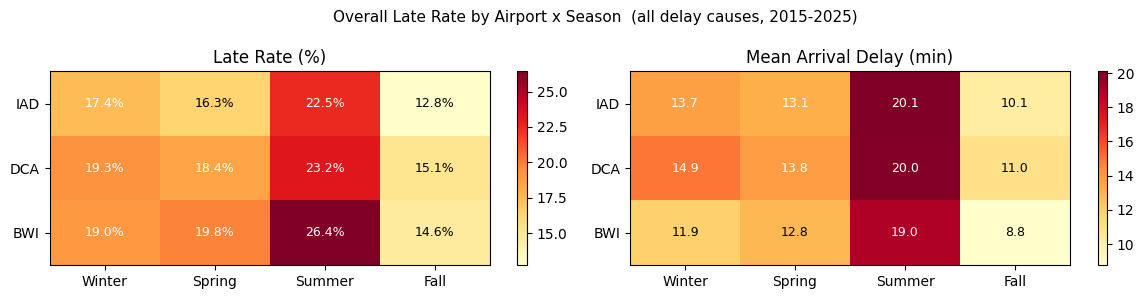

Best / worst season per airport (overall late rate):
  IAD:  best Fall (12.8%)  |  worst Summer (22.5%)
  DCA:  best Fall (15.1%)  |  worst Summer (23.2%)
  BWI:  best Fall (14.6%)  |  worst Summer (26.4%)


In [6]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
ap_season = (
    operated.groupby(['Origin', 'season'])
    .agg(
        late_pct   = ('is_late',         'mean'),
        mean_delay = ('ArrDelayMinutes', 'mean'),
        n_flights  = ('ArrDelayMinutes', 'count'),
    )
    .reset_index()
)

pivot_late  = ap_season.pivot(index='Origin', columns='season', values='late_pct')[season_order] * 100
pivot_delay = ap_season.pivot(index='Origin', columns='season', values='mean_delay')[season_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for ax, hmap, title, fmt in zip(
    axes,
    [pivot_late, pivot_delay],
    ['Late Rate (%)', 'Mean Arrival Delay (min)'],
    ['{:.1f}%', '{:.1f}'],
):
    data = hmap.reindex(AIRPORTS).values.astype(float)
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto',
                   vmin=np.nanmin(data), vmax=np.nanmax(data))
    ax.set_xticks(range(len(season_order)))
    ax.set_xticklabels(season_order)
    ax.set_yticks(range(len(AIRPORTS)))
    ax.set_yticklabels(AIRPORTS)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(len(AIRPORTS)):
        for j in range(len(season_order)):
            v = data[i, j]
            if not np.isnan(v):
                txt = fmt.format(v)
                ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                        color='white' if v > (np.nanmax(data) * 0.65) else 'black')

plt.suptitle('Overall Late Rate by Airport x Season  (all delay causes, 2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

best_season  = pivot_late.reindex(AIRPORTS).idxmin(axis=1)
worst_season = pivot_late.reindex(AIRPORTS).idxmax(axis=1)
print('Best / worst season per airport (overall late rate):')
for ap in AIRPORTS:
    b  = best_season[ap]
    w  = worst_season[ap]
    bv = pivot_late.loc[ap, b]
    wv = pivot_late.loc[ap, w]
    print(f'  {ap}:  best {b} ({bv:.1f}%)  |  worst {w} ({wv:.1f}%)')

## Section 6 — Carrier On-Time Performance by Airport

Using the full flight-level dataset (not monthly T-100 aggregates), we compute each
carrier's late rate at each DMV airport. Carriers with fewer than 2,000 operated
flights at an airport are excluded to keep comparisons statistically meaningful.

**Carrier code reference:**

| Code | Airline | Code | Airline |
|------|---------|------|---------|
| AA | American Airlines | NK | Spirit Airlines |
| AS | Alaska Airlines | OH | PSA Airlines (American Eagle) |
| B6 | JetBlue Airways | OO | SkyWest Airlines |
| DL | Delta Air Lines | UA | United Airlines |
| EV | ExpressJet Airlines | US | US Airways (merged into AA, 2015) |
| F9 | Frontier Airlines | VX | Virgin America (acq. by Alaska, 2018) |
| G4 | Allegiant Air | WN | Southwest Airlines |
| MQ | Envoy Air (American Eagle) | YV | Mesa Air |
| 9E | Endeavor Air (Delta Connection) | YX | Republic Airways |

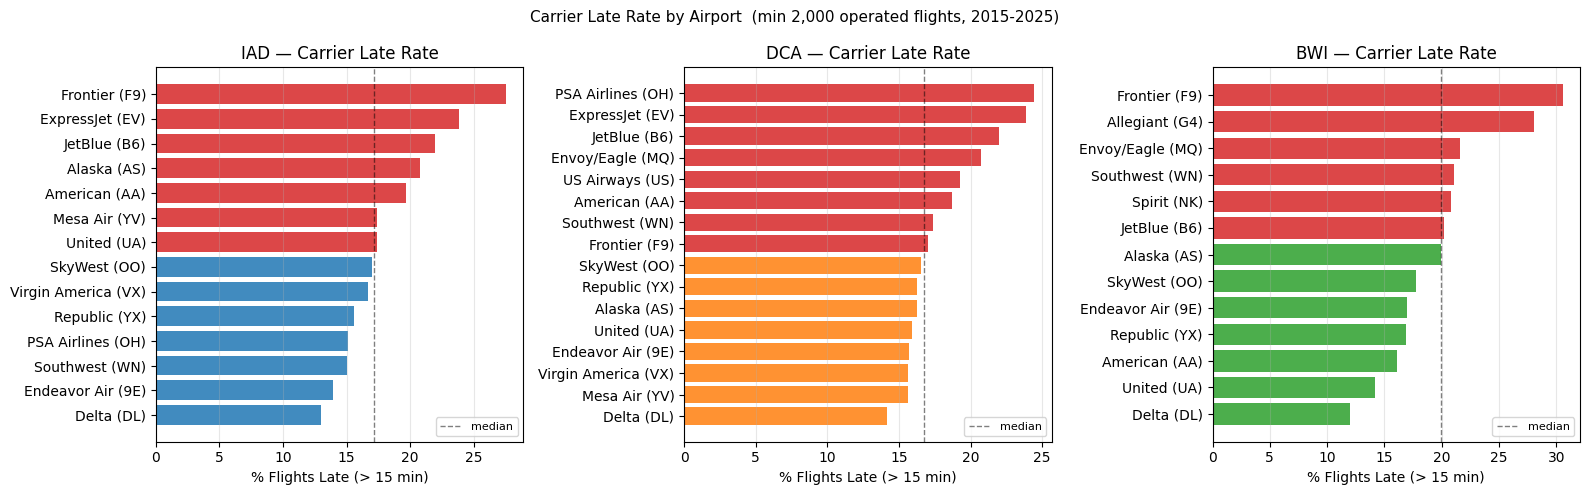

In [7]:
CARRIER_NAMES = {
    '9E': 'Endeavor Air (9E)',   'AA': 'American (AA)',
    'AS': 'Alaska (AS)',         'B6': 'JetBlue (B6)',
    'DL': 'Delta (DL)',          'EV': 'ExpressJet (EV)',
    'F9': 'Frontier (F9)',       'G4': 'Allegiant (G4)',
    'MQ': 'Envoy/Eagle (MQ)',    'NK': 'Spirit (NK)',
    'OH': 'PSA Airlines (OH)',   'OO': 'SkyWest (OO)',
    'UA': 'United (UA)',         'US': 'US Airways (US)',
    'VX': 'Virgin America (VX)', 'WN': 'Southwest (WN)',
    'YV': 'Mesa Air (YV)',       'YX': 'Republic (YX)',
}

carrier_ap = (
    operated.groupby(['Origin', 'Reporting_Airline'])
    .agg(
        late_pct   = ('is_late',         'mean'),
        mean_delay = ('ArrDelayMinutes', 'mean'),
        n_flights  = ('ArrDelayMinutes', 'count'),
    )
    .reset_index()
)
carrier_ap = carrier_ap[carrier_ap['n_flights'] >= 2000].copy()
carrier_ap['late_pct_disp'] = carrier_ap['late_pct'] * 100
carrier_ap['carrier_label'] = carrier_ap['Reporting_Airline'].map(CARRIER_NAMES).fillna(carrier_ap['Reporting_Airline'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, ap in zip(axes, AIRPORTS):
    sub = carrier_ap[carrier_ap['Origin'] == ap].sort_values('late_pct')
    median_late = sub['late_pct_disp'].median()
    bar_colors = [AIRPORT_COLORS[ap] if r['late_pct_disp'] <= median_late else '#d62728'
                  for _, r in sub.iterrows()]
    ax.barh(sub['carrier_label'], sub['late_pct_disp'], color=bar_colors, alpha=0.85)
    ax.axvline(median_late, color='black', linestyle='--', linewidth=1, alpha=0.5, label='median')
    ax.set_title(f'{ap} — Carrier Late Rate')
    ax.set_xlabel('% Flights Late (> 15 min)')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Carrier Late Rate by Airport  (min 2,000 operated flights, 2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 7 — Route Monopoly and On-Time Rate

Does a carrier's competitive position on a route correlate with its on-time performance?
`t100_carrier_share` measures the fraction of that route's monthly departures the carrier
holds. We bin routes into four tiers and compare delay rates — watching for whether
monopoly routes show a different profile than contested ones.

                      Mean Delay  Late %  Flights
share_bin                                        
Contested (<40%)          15.120    19.2   652402
Competitive (40-70%)      13.896    18.0   784406
Dominant (70-90%)         13.795    18.5   402814
Monopoly (>90%)           13.866    20.0   908247



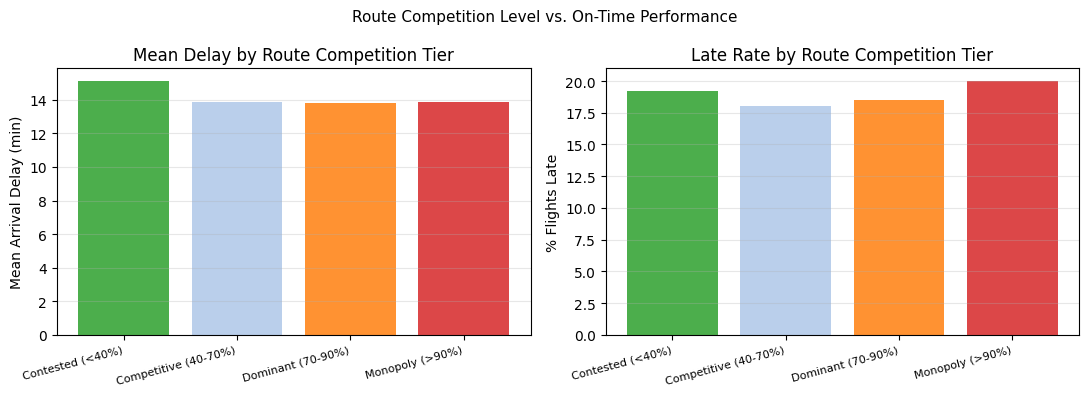

In [8]:
share_data = operated[operated['t100_carrier_share'].notna()].copy()
share_data['share_bin'] = pd.cut(
    share_data['t100_carrier_share'],
    bins=[0, 0.4, 0.7, 0.9, 1.001],
    labels=['Contested (<40%)', 'Competitive (40-70%)', 'Dominant (70-90%)', 'Monopoly (>90%)'],
)

share_stats = (
    share_data.groupby('share_bin', observed=True)
    .agg(
        late_pct   = ('is_late',          'mean'),
        mean_delay = ('ArrDelayMinutes',  'mean'),
        n_flights  = ('ArrDelayMinutes',  'count'),
    )
    .round(3)
)
share_stats['late_pct_disp'] = (share_stats['late_pct'] * 100).round(1)
print(share_stats[['mean_delay', 'late_pct_disp', 'n_flights']].rename(
    columns={'mean_delay':'Mean Delay','late_pct_disp':'Late %','n_flights':'Flights'}
).to_string())
print()

tiers = share_stats.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tier_colors = ['#2ca02c', '#aec7e8', '#ff7f0e', '#d62728']

ax = axes[0]
ax.bar(range(len(tiers)), share_stats['mean_delay'], color=tier_colors, alpha=0.85)
ax.set_xticks(range(len(tiers)))
ax.set_xticklabels(tiers, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Mean Arrival Delay (min)')
ax.set_title('Mean Delay by Route Competition Tier')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(range(len(tiers)), share_stats['late_pct_disp'], color=tier_colors, alpha=0.85)
ax.set_xticks(range(len(tiers)))
ax.set_xticklabels(tiers, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('% Flights Late')
ax.set_title('Late Rate by Route Competition Tier')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Route Competition Level vs. On-Time Performance', fontsize=11)
plt.tight_layout()
plt.show()

## Section 8 — Fare Level vs. Delay

DB1B average nonstop fare proxies for route type: high-fare thin markets tend to be
business-driven; low-fare dense markets are leisure-dominated.
We split matched flights into fare quartiles and compare on-time performance —
watching for whether premium routes are better protected.

         Avg Fare ($)  Mean Delay  Late %  Flights
fare_q                                            
Q1 Low         143.91       13.04    18.0   644148
Q2             192.25       13.55    19.0   645185
Q3             228.36       14.52    19.0   642638
Q4 High        322.70       14.39    19.0   643127



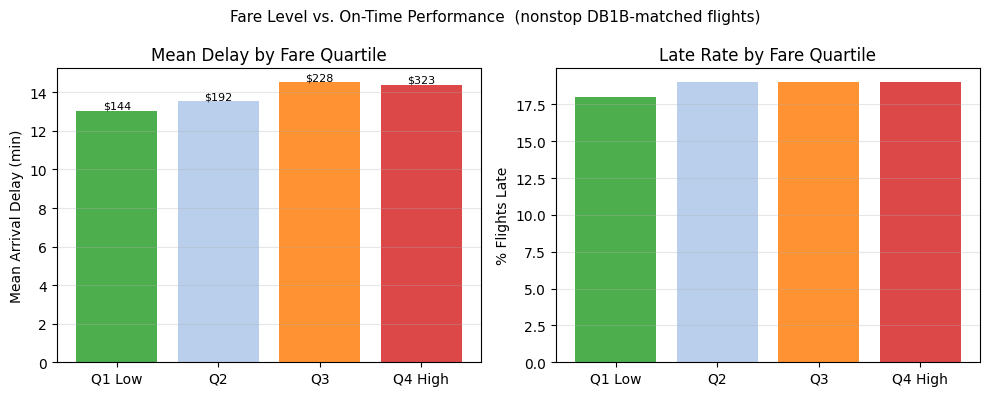

In [9]:
fare_data = operated[operated['db1b_avg_fare'].notna()].copy()
fare_data['fare_q'] = pd.qcut(
    fare_data['db1b_avg_fare'], 4,
    labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'],
    duplicates='drop',
)

fare_stats = (
    fare_data.groupby('fare_q', observed=True)
    .agg(
        avg_fare   = ('db1b_avg_fare',    'mean'),
        late_pct   = ('is_late',          'mean'),
        mean_delay = ('ArrDelayMinutes',  'mean'),
        n_flights  = ('ArrDelayMinutes',  'count'),
    )
    .round(2)
)
fare_stats['late_pct_disp'] = (fare_stats['late_pct'] * 100).round(1)
print(fare_stats[['avg_fare','mean_delay','late_pct_disp','n_flights']].rename(
    columns={'avg_fare':'Avg Fare ($)','mean_delay':'Mean Delay','late_pct_disp':'Late %','n_flights':'Flights'}
).to_string())
print()

qs = fare_stats.index.tolist()
q_colors = ['#2ca02c', '#aec7e8', '#ff7f0e', '#d62728']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.bar(range(len(qs)), fare_stats['mean_delay'], color=q_colors, alpha=0.85)
ax.set_xticks(range(len(qs)))
ax.set_xticklabels(qs)
ax.set_ylabel('Mean Arrival Delay (min)')
ax.set_title('Mean Delay by Fare Quartile')
avg_fares = [f'${fare_stats.loc[q, "avg_fare"]:.0f}' for q in qs]
for i, lbl in enumerate(avg_fares):
    ax.text(i, fare_stats['mean_delay'].iloc[i] + 0.1, lbl, ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(range(len(qs)), fare_stats['late_pct_disp'], color=q_colors, alpha=0.85)
ax.set_xticks(range(len(qs)))
ax.set_xticklabels(qs)
ax.set_ylabel('% Flights Late')
ax.set_title('Late Rate by Fare Quartile')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fare Level vs. On-Time Performance  (nonstop DB1B-matched flights)', fontsize=11)
plt.tight_layout()
plt.show()

## Section 9 — International Feeder Airports into DMV

BTS on-time data only captures departures, and DB1B covers US domestic markets only.
To see which **international** airports feed each DMV hub we use the T-100 International
Segment data (`t100_intl_dmv.parquet`), which records every foreign-origin → DMV-destination
segment flown by US and foreign carriers.

Note: DCA has very limited international service due to its slot-controlled perimeter rule
(most international routes require a slot waiver). IAD and BWI carry the bulk of
international inbound traffic for the region.

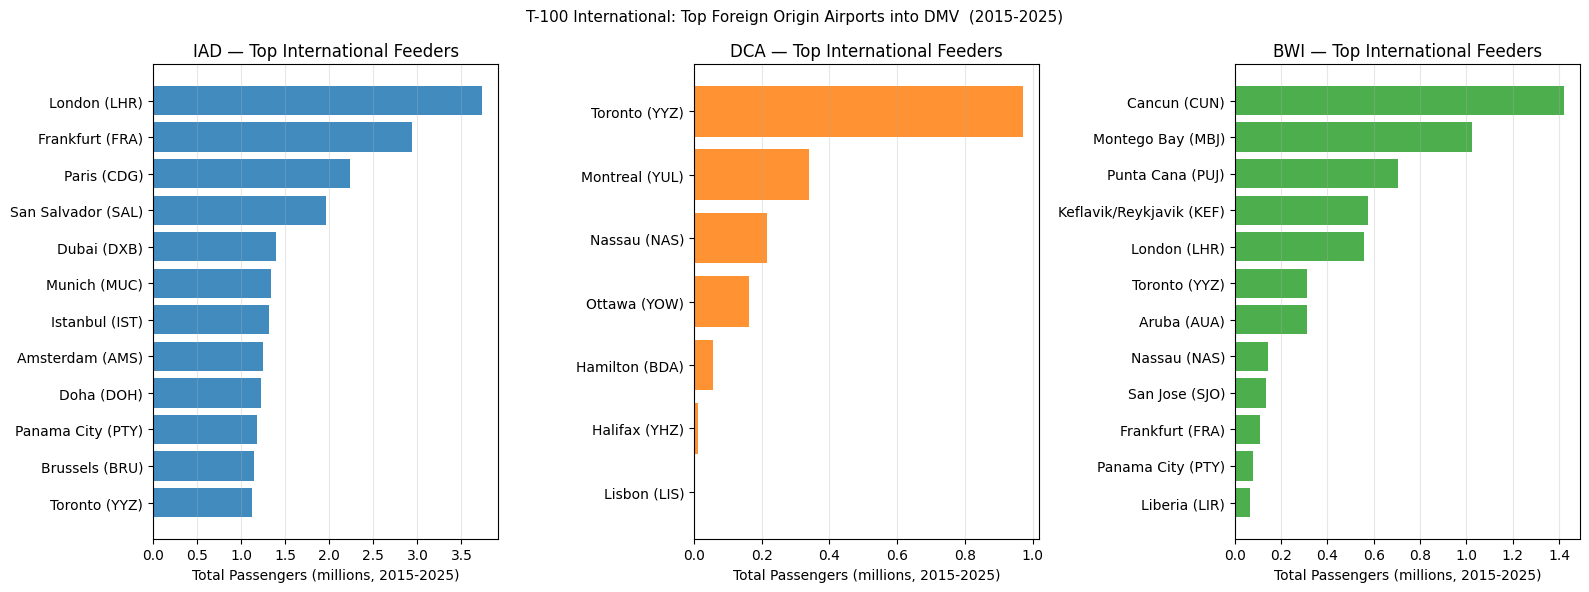

Top 5 international origin airports per destination:
  IAD: LHR (3730K pax), FRA (2943K pax), CDG (2239K pax), SAL (1959K pax), DXB (1396K pax)
  DCA: YYZ (971K pax), YUL (340K pax), NAS (215K pax), YOW (162K pax), BDA (58K pax)
  BWI: CUN (1420K pax), MBJ (1023K pax), PUJ (706K pax), KEF (574K pax), LHR (557K pax)


In [10]:
t100_intl = pd.read_parquet(
    PROJECT_ROOT / PROCESSED_DATA_PATH / 't100_intl_dmv.parquet',
    columns=['ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'PASSENGERS', 'UNIQUE_CARRIER', 'YEAR'],
)
# Already filtered to DMV destinations with foreign origins in ingestion
# Aggregate total passengers by origin airport → DMV airport
intl_pax = (
    t100_intl.groupby(['ORIGIN', 'ORIGIN_CITY_NAME', 'DEST'])['PASSENGERS']
    .sum()
    .reset_index()
    .rename(columns={'PASSENGERS': 'total_pax'})
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, ap in zip(axes, AIRPORTS):
    sub = (
        intl_pax[intl_pax['DEST'] == ap]
        .nlargest(12, 'total_pax')
        .copy()
    )
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{ap} — International Feeders')
        continue

    sub['city'] = sub['ORIGIN_CITY_NAME'].str.split(',').str[0].str.strip()
    sub['label'] = sub['city'] + ' (' + sub['ORIGIN'] + ')'
    sub = sub.sort_values('total_pax')
    ax.barh(sub['label'], sub['total_pax'] / 1e6, color=AIRPORT_COLORS[ap], alpha=0.85)
    ax.set_title(f'{ap} — Top International Feeders')
    ax.set_xlabel('Total Passengers (millions, 2015-2025)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('T-100 International: Top Foreign Origin Airports into DMV  (2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 5 international origin airports per destination:')
for ap in AIRPORTS:
    sub = intl_pax[intl_pax['DEST'] == ap].nlargest(5, 'total_pax')
    rows = [f"{r['ORIGIN']} ({r['total_pax']/1e3:.0f}K pax)" for _, r in sub.iterrows()]
    print(f'  {ap}: {", ".join(rows) if rows else "no data"}')

## Section 11 — NAS Delay Trend: The Staffing Crisis Signal

NAS (National Airspace System) delays are assigned when ATC capacity, ground delay programs,
or flow-control programs — not the carrier or weather — absorb the delay. A rising NAS share
of total delay minutes after 2020 would be consistent with the FAA controller staffing
shortage: retirements accelerated during COVID, training pipelines stalled, and operational
shortfalls were widely reported from 2022 onward.

A sharp upturn from 2022+ is the staffing-crisis signature. Note: the 2020 COVID dip
distorts the denominator (far fewer total flights = NAS share is less stable that year).

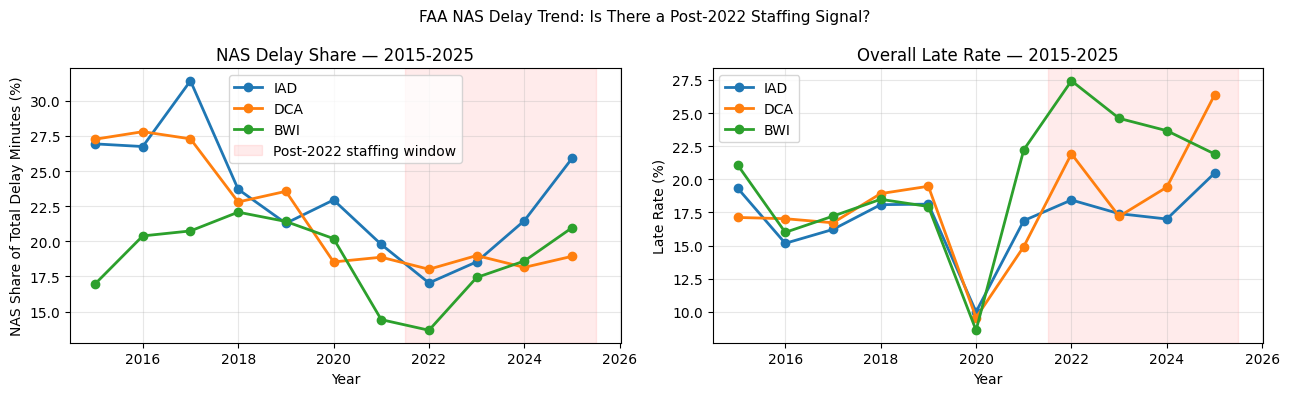

NAS share: pre-COVID avg (2015-2019) vs post-2022 avg (2022-2025):
  IAD: 26.0% → 20.7%  (Δ -5.3 pp)
  DCA: 25.7% → 18.5%  (Δ -7.2 pp)
  BWI: 20.3% → 17.7%  (Δ -2.7 pp)


In [11]:
nas_trend = (
    operated.groupby(['Year', 'Origin'])
    .agg(
        nas_minutes         = ('NASDelay',        'sum'),
        total_delay_minutes = ('ArrDelayMinutes', 'sum'),
        total_flights       = ('is_late',         'count'),
        late_flights        = ('is_late',         lambda x: x.fillna(0).sum()),
    )
    .reset_index()
)
nas_trend['nas_share'] = nas_trend['nas_minutes'] / nas_trend['total_delay_minutes'].replace(0, np.nan)
nas_trend['late_rate']  = nas_trend['late_flights'] / nas_trend['total_flights']
nas_trend = nas_trend[nas_trend['Year'] <= 2025]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for ap in AIRPORTS:
    sub = nas_trend[nas_trend['Origin'] == ap]
    ax.plot(sub['Year'], sub['nas_share'] * 100, marker='o',
            color=AIRPORT_COLORS[ap], label=ap, linewidth=2)
ax.axvspan(2021.5, 2025.5, alpha=0.08, color='red', label='Post-2022 staffing window')
ax.set_xlabel('Year')
ax.set_ylabel('NAS Share of Total Delay Minutes (%)')
ax.set_title('NAS Delay Share — 2015-2025')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for ap in AIRPORTS:
    sub = nas_trend[nas_trend['Origin'] == ap]
    ax.plot(sub['Year'], sub['late_rate'] * 100, marker='o',
            color=AIRPORT_COLORS[ap], label=ap, linewidth=2)
ax.axvspan(2021.5, 2025.5, alpha=0.08, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Late Rate (%)')
ax.set_title('Overall Late Rate — 2015-2025')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('FAA NAS Delay Trend: Is There a Post-2022 Staffing Signal?', fontsize=11)
plt.tight_layout()
plt.show()

print('NAS share: pre-COVID avg (2015-2019) vs post-2022 avg (2022-2025):')
for ap in AIRPORTS:
    pre  = nas_trend[(nas_trend['Origin'] == ap) & nas_trend['Year'].between(2015, 2019)]['nas_share'].mean()
    post = nas_trend[(nas_trend['Origin'] == ap) & nas_trend['Year'].between(2022, 2025)]['nas_share'].mean()
    print(f'  {ap}: {pre*100:.1f}% → {post*100:.1f}%  (Δ {(post-pre)*100:+.1f} pp)')

## Section 12 — Carrier Market Share by Airport

Each DMV airport has a distinct competitive character: Southwest's point-to-point model
dominates BWI; Reagan (DCA) splits traffic among legacies and Southwest; Dulles (IAD)
is heavily United-weighted due to its hub status. This shapes delay profiles — a hub
airport inherits connecting-bank congestion that a point-to-point airport avoids.

Carriers with less than 2% share are grouped as "Other". See Section 6 for the full carrier code reference.

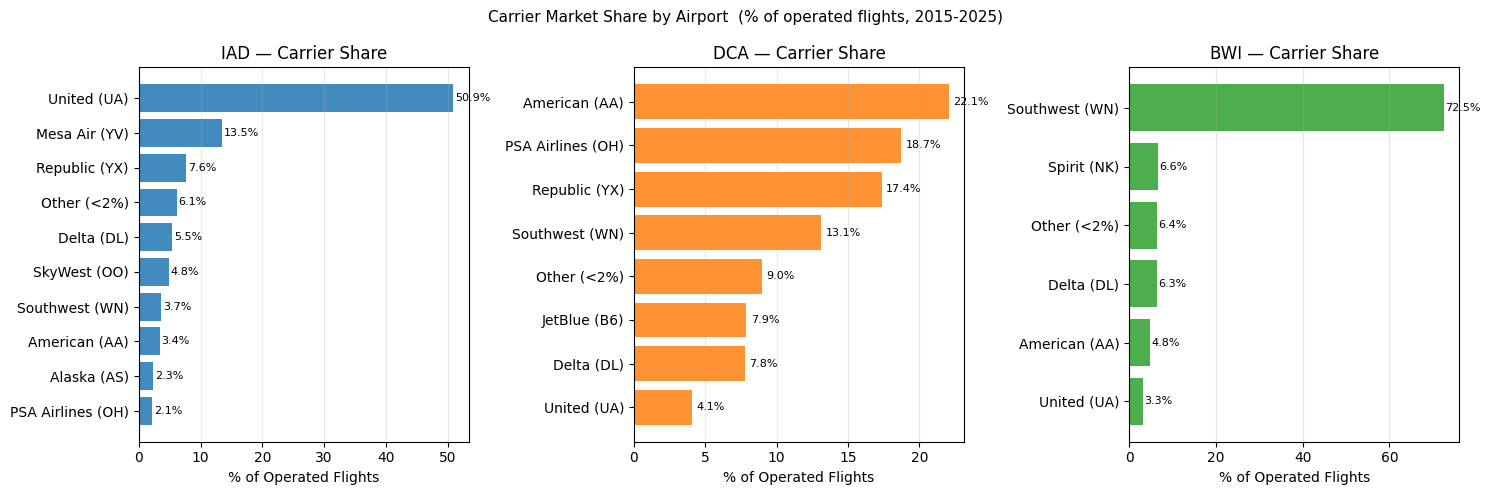

Top 3 carriers by airport:
  IAD: United (UA) (50.9%) | Mesa Air (YV) (13.5%) | Republic (YX) (7.6%)
  DCA: American (AA) (22.1%) | PSA Airlines (OH) (18.7%) | Republic (YX) (17.4%)
  BWI: Southwest (WN) (72.5%) | Spirit (NK) (6.6%) | Delta (DL) (6.3%)


In [12]:
share = (
    operated.groupby(['Origin', 'Reporting_Airline'])
    .size()
    .reset_index(name='flights')
)
share['pct'] = share.groupby('Origin')['flights'].transform(lambda x: x / x.sum() * 100)
share['carrier_label'] = share['Reporting_Airline'].map(CARRIER_NAMES).fillna(share['Reporting_Airline'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ap in zip(axes, AIRPORTS):
    sub = share[share['Origin'] == ap].copy()
    top = sub[sub['pct'] >= 2].sort_values('pct', ascending=False)
    other_pct = sub[sub['pct'] < 2]['pct'].sum()
    if other_pct > 0.1:
        other_row = pd.DataFrame([{'carrier_label': 'Other (<2%)', 'pct': other_pct}])
        top = pd.concat([top[['carrier_label', 'pct']], other_row], ignore_index=True)
    top = top.sort_values('pct')
    ax.barh(top['carrier_label'], top['pct'], color=AIRPORT_COLORS[ap], alpha=0.85)
    ax.set_title(f'{ap} — Carrier Share')
    ax.set_xlabel('% of Operated Flights')
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(top.reset_index(drop=True).iterrows()):
        ax.text(row['pct'] + 0.3, i, f"{row['pct']:.1f}%", va='center', fontsize=8)

plt.suptitle('Carrier Market Share by Airport  (% of operated flights, 2015-2025)', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 3 carriers by airport:')
for ap in AIRPORTS:
    top3 = share[share['Origin'] == ap].nlargest(3, 'pct')[['carrier_label', 'pct']]
    rows = [f"{r['carrier_label']} ({r['pct']:.1f}%)" for _, r in top3.iterrows()]
    print(f'  {ap}: {" | ".join(rows)}')

## Section 13 — Annual Flight Volume and the COVID Dip

COVID-19 produced the sharpest demand shock in US aviation history. The 2020 trough and
the shape of the 2021-2022 recovery varied by airport depending on carrier mix — low-cost
carriers (Southwest at BWI, Spirit/JetBlue at DCA) tend to recover faster than legacy
carriers rebuilding international networks (United at IAD).

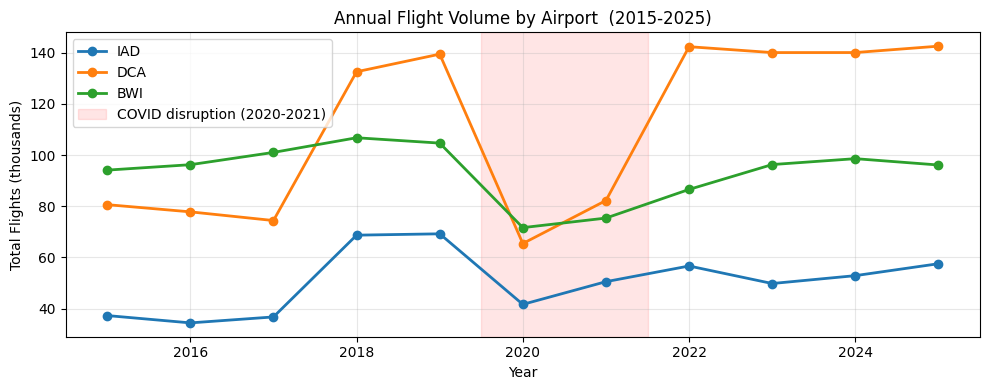

COVID impact — 2019 → 2020 → 2023 recovery check:
  IAD: 2019=69,223  2020=41,668 (40% drop)  2023=49,815 (72% of 2019 baseline)
  DCA: 2019=139,388  2020=65,432 (53% drop)  2023=140,005 (100% of 2019 baseline)
  BWI: 2019=104,652  2020=71,641 (32% drop)  2023=96,271 (92% of 2019 baseline)


In [13]:
vol = (
    feat.groupby(['Year', 'Origin'])
    .size()
    .reset_index(name='flights')
)
vol = vol[vol['Year'] <= 2025]

fig, ax = plt.subplots(figsize=(10, 4))
for ap in AIRPORTS:
    sub = vol[vol['Origin'] == ap]
    ax.plot(sub['Year'], sub['flights'] / 1e3, marker='o',
            color=AIRPORT_COLORS[ap], label=ap, linewidth=2)

ax.axvspan(2019.5, 2021.5, alpha=0.1, color='red', label='COVID disruption (2020-2021)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Flights (thousands)')
ax.set_title('Annual Flight Volume by Airport  (2015-2025)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('COVID impact — 2019 → 2020 → 2023 recovery check:')
for ap in AIRPORTS:
    v19 = vol.loc[(vol['Origin'] == ap) & (vol['Year'] == 2019), 'flights'].values[0]
    v20 = vol.loc[(vol['Origin'] == ap) & (vol['Year'] == 2020), 'flights'].values[0]
    v23 = vol.loc[(vol['Origin'] == ap) & (vol['Year'] == 2023), 'flights'].values[0]
    print(f'  {ap}: 2019={v19:,}  2020={v20:,} ({(v19-v20)/v19*100:.0f}% drop)'
          f'  2023={v23:,} ({v23/v19*100:.0f}% of 2019 baseline)')

## Section 14 — Shared Destination Markets

All three DMV airports serve many of the same destinations, creating natural controlled
comparisons: for a given O-D pair, does IAD, DCA, or BWI deliver better on-time performance?
These shared routes remove route-level demand and distance as confounders and are the
foundation for the airport-vs-airport analysis in Part 4 of the blog.

Threshold: destinations with > 500 operated flights from **each** of the three airports
over 2015-2025.

Destinations served by all three airports (> 500 flights each): 52

Origin      BWI      DCA      IAD
Dest                             
ATL     64194.0  67993.0  38012.0
DEN     28494.0  15174.0  34937.0
SFO      5515.0   7560.0  32039.0
LAX     17551.0  14707.0  31252.0
CLT     35567.0  31790.0  20669.0
ORD     28792.0  67598.0  19202.0
MCO     48653.0  41225.0  18608.0
DFW     16557.0  33257.0  18301.0
BOS     46197.0  89219.0  18011.0
SEA      7230.0   8057.0  17232.0
IAH     11224.0  22875.0  16917.0
DTW     26684.0  27016.0  15547.0
EWR      1812.0  12696.0  12912.0
TPA     30265.0  23674.0  11567.0
MSP     16586.0  24314.0  11384.0
RDU     20944.0  16025.0  10724.0
JFK      7728.0  19990.0  10004.0
LAS     20332.0   4083.0   9817.0
BDL     20453.0  15336.0   8918.0
AUS     10868.0   3759.0   8892.0



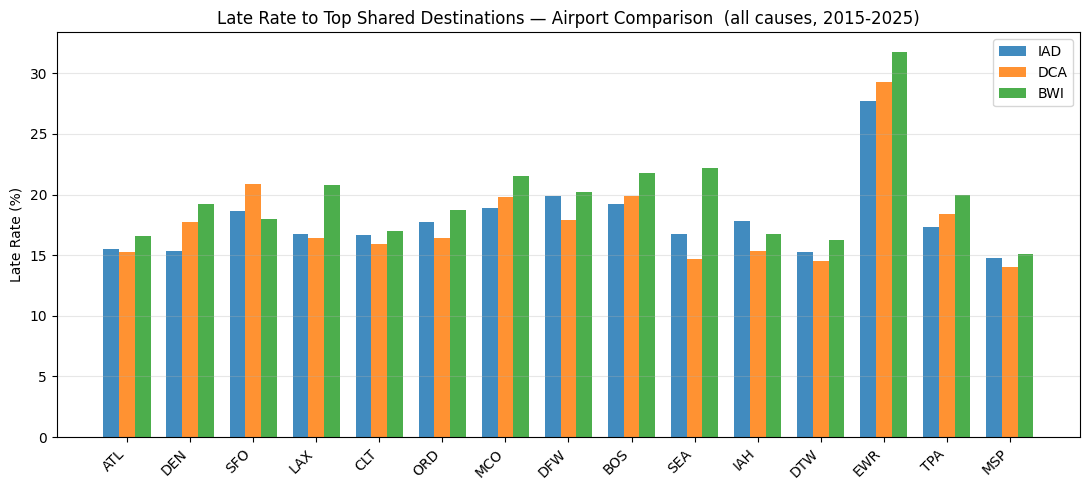

In [14]:
shared = (
    operated.groupby(['Origin', 'Dest'])
    .size()
    .reset_index(name='flights')
)
pivot_dest = shared.pivot(index='Dest', columns='Origin', values='flights').fillna(0)
all_three = pivot_dest[(pivot_dest > 500).all(axis=1)].sort_values('IAD', ascending=False)

print(f'Destinations served by all three airports (> 500 flights each): {len(all_three)}')
print()
print(all_three.head(20).to_string())
print()

# Late rate on the top shared routes — the cleanest airport comparison
top_dests = all_three.head(15).index.tolist()
late_by_dest = (
    operated[operated['Dest'].isin(top_dests)]
    .groupby(['Origin', 'Dest'])
    .agg(late_rate=('is_late', 'mean'))
    .reset_index()
)
late_pivot = late_by_dest.pivot(index='Dest', columns='Origin', values='late_rate') * 100
late_pivot = late_pivot.reindex(top_dests)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top_dests))
w = 0.25
for i, ap in enumerate(AIRPORTS):
    if ap in late_pivot.columns:
        ax.bar(x + i * w, late_pivot[ap], w, label=ap, color=AIRPORT_COLORS[ap], alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(top_dests, rotation=45, ha='right')
ax.set_ylabel('Late Rate (%)')
ax.set_title('Late Rate to Top Shared Destinations — Airport Comparison  (all causes, 2015-2025)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 10 — Summary & Key Findings

In [15]:
print('=== Key Findings: Joined EDA (flights_featured, 2015-2025) ===')
print()
print('1. Visibility shows a step-change at the IFR threshold.')
if 'vis_stats' in dir():
    lifr_d  = vis_stats.loc['LIFR (<1 mi)',  'mean_delay']
    clear_d = vis_stats.loc['Clear (>10 mi)','mean_delay']
    print(f'   LIFR days average {lifr_d:.1f} min delay vs {clear_d:.1f} min on clear days.')
print()
print('2. Thunderstorm vs. snow vs. fog — distinct delay profiles.')
if 'wx_stats' in dir():
    for wt in ['Thunderstorm', 'Snow', 'Fog / Mist']:
        d = wx_stats.loc[wt, 'mean_delay']
        l = wx_stats.loc[wt, 'late_pct_disp']
        print(f'   {wt:<14}: {d:.1f} min mean delay, {l:.1f}% late')
print()
print('3. Afternoon departures pay the largest thunderstorm penalty.')
if 'ts_pivot' in dir():
    pm = ts_pivot['lift'].idxmax()
    pv = ts_pivot.loc[pm, 'lift']
    print(f'   {pm} window: +{pv:.1f} min extra delay on storm days.')
print()
print('4. Season x airport: each airport has a distinct worst season.')
print()
print('5. Route competition and fare level are correlated with delay,')
print('   but causation is not established. Long-haul monopoly routes have')
print('   fundamentally different delay profiles than short-haul contested')
print('   routes — confounded by distance, route type, and carrier composition.')
print('   Treat as correlation only; control for distance before drawing')
print('   stronger conclusions in the modeling notebook.')
print()
print('Next: 09_modeling.ipynb')

=== Key Findings: Joined EDA (flights_featured, 2015-2025) ===

1. Visibility shows a step-change at the IFR threshold.
   LIFR days average 23.8 min delay vs 10.9 min on clear days.

2. Thunderstorm vs. snow vs. fog — distinct delay profiles.
   Thunderstorm  : 32.0 min mean delay, 33.1% late
   Snow          : 23.9 min mean delay, 30.4% late
   Fog / Mist    : 14.7 min mean delay, 21.0% late

3. Afternoon departures pay the largest thunderstorm penalty.
   Evening window: +43.1 min extra delay on storm days.

4. Season x airport: each airport has a distinct worst season.

5. Route competition and fare level are correlated with delay,
   but causation is not established. Long-haul monopoly routes have
   fundamentally different delay profiles than short-haul contested
   routes — confounded by distance, route type, and carrier composition.
   Treat as correlation only; control for distance before drawing
   stronger conclusions in the modeling notebook.

Next: 09_modeling.ipynb
